In [29]:
# Importing standard packages for data exploration and processing.
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 100)

In [30]:
# We do not want most of the columns for this analysis.
columns = ['Profile', 'Year', 'Team_id', 'Match_id', 'Team', 'Home_team', 'Winner']

skaters_match = pd.read_csv('../data/skaters_match.csv', usecols=columns)
goalies_match = pd.read_csv('../data/goalies_match.csv', usecols=columns)

# Those columns are the same for both skaters and goalies.

players_match = skaters_match.append(goalies_match, ignore_index=True)
players_match.head(5)

,Profile,Team_id,Match_id,Year,Team,Home_team,Winner
0,https://en.khl.ru/players/16673/,54,6993,2013/2014,Amur,Barys,Barys
1,https://en.khl.ru/players/16673/,54,7869,2013/2014,Amur,Amur,Amur
2,https://en.khl.ru/players/16673/,54,9037,2013/2014,Amur,Amur,SKA
3,https://en.khl.ru/players/16673/,54,9701,2013/2014,Amur,Amur,Atlant
4,https://en.khl.ru/players/16673/,54,10343,2013/2014,Amur,Amur,Severstal


In [31]:
players_match = players_match[players_match['Year'] == '2019/2020']
players_match.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 31922 entries, 317 to 422645
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Profile    31922 non-null  object
 1   Team_id    31922 non-null  int64 
 2   Match_id   31922 non-null  int64 
 3   Year       31922 non-null  object
 4   Team       31922 non-null  object
 5   Home_team  31922 non-null  object
 6   Winner     31922 non-null  object
dtypes: int64(2), object(5)
memory usage: 1.9+ MB


In [32]:
# We need to know whether a player has played for the home team and whether the home team has won.
players_match['Home'] = np.where(players_match['Team'] == players_match['Home_team'], 1, 0)
players_match['Win'] = np.where(players_match['Home_team'] == players_match['Winner'], 1, 0)
players_match.head()

,Profile,Team_id,Match_id,Year,Team,Home_team,Winner,Home,Win
317,https://en.khl.ru/players/34493/,38,319,2019/2020,Salavat Yulaev,Salavat Yulaev,Salavat Yulaev,1,1
318,https://en.khl.ru/players/34493/,38,9972,2019/2020,Salavat Yulaev,Neftekhimik,Salavat Yulaev,0,0
319,https://en.khl.ru/players/34493/,38,7150,2019/2020,Salavat Yulaev,Amur,Amur,0,1
320,https://en.khl.ru/players/34493/,38,2710,2019/2020,Salavat Yulaev,Salavat Yulaev,Salavat Yulaev,1,1
321,https://en.khl.ru/players/34493/,38,5875,2019/2020,Salavat Yulaev,Ak Bars,Ak Bars,0,1


In [33]:
# We can use the match ID to turn the player-match level data into team-match level data.
wins = players_match[['Match_id', 'Win']].groupby('Match_id').max()
wins.head()

,Win
Match_id,
60,1
61,1
62,0
63,1
64,0


In [34]:
wins.describe()

,Win
count,784.000000
mean,0.554847
std,0.497300
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,1.000000


In [39]:
Some columns have already served their purpose and some need to be objects to get dummies.
players_match = players_match.drop(['Year', 'Team', 'Home_team', 'Winner', 'Win'], axis=1)
players_match = players_match.astype('string')
players_match['Profile|team'] = players_match['Profile'] + '|' + players_match['Team_id']
players_match.head()

,Profile,Team_id,Match_id,Home,Profile|team
317,https://en.khl.ru/players/34493/,38,319,1,https://en.khl.ru/players/34493/|38
318,https://en.khl.ru/players/34493/,38,9972,0,https://en.khl.ru/players/34493/|38
319,https://en.khl.ru/players/34493/,38,7150,0,https://en.khl.ru/players/34493/|38
320,https://en.khl.ru/players/34493/,38,2710,1,https://en.khl.ru/players/34493/|38
321,https://en.khl.ru/players/34493/,38,5875,0,https://en.khl.ru/players/34493/|38


In [58]:
players_match.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 31922 entries, 317 to 422645
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Profile       31922 non-null  string
 1   Team_id       31922 non-null  string
 2   Match_id      31922 non-null  string
 3   Home          31922 non-null  string
 4   Profile|team  31922 non-null  string
dtypes: string(5)
memory usage: 1.5 MB


In [59]:
# Careful not to get the match ID dummies.
# We are getting the dummies as floats so that we can have negative values for the dummies of the away team.
list_dummies = ['Team_id', 'Profile', 'Profile|team']
players_dummies = pd.get_dummies(data=players_match, columns=list_dummies, dtype='float16')
players_dummies.head()

,Match_id,Home,Team_id_1,Team_id_19,Team_id_190,Team_id_198,Team_id_2,Team_id_207,Team_id_208,Team_id_24,Team_id_25,Team_id_26,Team_id_29,Team_id_34,Team_id_37,Team_id_38,Team_id_418,Team_id_450,Team_id_451,Team_id_53,Team_id_54,Team_id_56,Team_id_568,Team_id_7,Team_id_71,Team_id_719,Profile_https://en.khl.ru/players/10162/,Profile_https://en.khl.ru/players/10176/,Profile_https://en.khl.ru/players/10546/,Profile_https://en.khl.ru/players/10769/,Profile_https://en.khl.ru/players/11032/,Profile_https://en.khl.ru/players/125/,Profile_https://en.khl.ru/players/12810/,Profile_https://en.khl.ru/players/13121/,Profile_https://en.khl.ru/players/13226/,Profile_https://en.khl.ru/players/13252/,Profile_https://en.khl.ru/players/13253/,Profile_https://en.khl.ru/players/13256/,Profile_https://en.khl.ru/players/13277/,Profile_https://en.khl.ru/players/13446/,Profile_https://en.khl.ru/players/13483/,Profile_https://en.khl.ru/players/13704/,Profile_https://en.khl.ru/players/13706/,Profile_https://en.khl.ru/players/13726/,Profile_https://en.khl.ru/players/13782/,Profile_https://en.khl.ru/players/13806/,Profile_https://en.khl.ru/players/13809/,Profile_https://en.khl.ru/players/13871/,Profile_https://en.khl.ru/players/13928/,Profile_https://en.khl.ru/players/13946/,...,Profile|team_https://en.khl.ru/players/35213/|207,Profile|team_https://en.khl.ru/players/35222/|207,Profile|team_https://en.khl.ru/players/35225/|568,Profile|team_https://en.khl.ru/players/3523/|34,Profile|team_https://en.khl.ru/players/35245/|207,Profile|team_https://en.khl.ru/players/35315/|208,Profile|team_https://en.khl.ru/players/35317/|568,Profile|team_https://en.khl.ru/players/35345/|198,Profile|team_https://en.khl.ru/players/35440/|568,Profile|team_https://en.khl.ru/players/3545/|25,Profile|team_https://en.khl.ru/players/3550/|37,Profile|team_https://en.khl.ru/players/35659/|71,Profile|team_https://en.khl.ru/players/35843/|568,Profile|team_https://en.khl.ru/players/35851/|207,Profile|team_https://en.khl.ru/players/35861/|568,Profile|team_https://en.khl.ru/players/35911/|207,Profile|team_https://en.khl.ru/players/3649/|56,Profile|team_https://en.khl.ru/players/3667/|26,Profile|team_https://en.khl.ru/players/372/|29,Profile|team_https://en.khl.ru/players/3989/|71,Profile|team_https://en.khl.ru/players/4101/|2,Profile|team_https://en.khl.ru/players/4107/|1,Profile|team_https://en.khl.ru/players/43/|208,Profile|team_https://en.khl.ru/players/4351/|56,Profile|team_https://en.khl.ru/players/4416/|53,Profile|team_https://en.khl.ru/players/4486/|54,Profile|team_https://en.khl.ru/players/4491/|719,Profile|team_https://en.khl.ru/players/4698/|190,Profile|team_https://en.khl.ru/players/494/|37,Profile|team_https://en.khl.ru/players/4967/|26,Profile|team_https://en.khl.ru/players/516/|719,Profile|team_https://en.khl.ru/players/524/|34,Profile|team_https://en.khl.ru/players/5403/|198,Profile|team_https://en.khl.ru/players/548/|7,Profile|team_https://en.khl.ru/players/5516/|37,Profile|team_https://en.khl.ru/players/5524/|38,Profile|team_https://en.khl.ru/players/5526/|418,Profile|team_https://en.khl.ru/players/5636/|451,Profile|team_https://en.khl.ru/players/5851/|7,Profile|team_https://en.khl.ru/players/587/|25,Profile|team_https://en.khl.ru/players/590/|207,Profile|team_https://en.khl.ru/players/5936/|19,Profile|team_https://en.khl.ru/players/595/|7,Profile|team_https://en.khl.ru/players/6395/|19,Profile|team_https://en.khl.ru/players/6428/|34,Profile|team_https://en.khl.ru/players/7211/|7,Profile|team_https://en.khl.ru/players/7640/|71,Profile|team_https://en.khl.ru/players/9467/|24,Profile|team_https://en.khl.ru/players/9476/|34,Profile|team_https://en.khl.ru/players/9849/|26
317,319,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.

In [60]:
players_dummies.head()

,Match_id,Home,Team_id_1,Team_id_19,Team_id_190,Team_id_198,Team_id_2,Team_id_207,Team_id_208,Team_id_24,Team_id_25,Team_id_26,Team_id_29,Team_id_34,Team_id_37,Team_id_38,Team_id_418,Team_id_450,Team_id_451,Team_id_53,Team_id_54,Team_id_56,Team_id_568,Team_id_7,Team_id_71,Team_id_719,Profile_https://en.khl.ru/players/10162/,Profile_https://en.khl.ru/players/10176/,Profile_https://en.khl.ru/players/10546/,Profile_https://en.khl.ru/players/10769/,Profile_https://en.khl.ru/players/11032/,Profile_https://en.khl.ru/players/125/,Profile_https://en.khl.ru/players/12810/,Profile_https://en.khl.ru/players/13121/,Profile_https://en.khl.ru/players/13226/,Profile_https://en.khl.ru/players/13252/,Profile_https://en.khl.ru/players/13253/,Profile_https://en.khl.ru/players/13256/,Profile_https://en.khl.ru/players/13277/,Profile_https://en.khl.ru/players/13446/,Profile_https://en.khl.ru/players/13483/,Profile_https://en.khl.ru/players/13704/,Profile_https://en.khl.ru/players/13706/,Profile_https://en.khl.ru/players/13726/,Profile_https://en.khl.ru/players/13782/,Profile_https://en.khl.ru/players/13806/,Profile_https://en.khl.ru/players/13809/,Profile_https://en.khl.ru/players/13871/,Profile_https://en.khl.ru/players/13928/,Profile_https://en.khl.ru/players/13946/,...,Profile|team_https://en.khl.ru/players/35213/|207,Profile|team_https://en.khl.ru/players/35222/|207,Profile|team_https://en.khl.ru/players/35225/|568,Profile|team_https://en.khl.ru/players/3523/|34,Profile|team_https://en.khl.ru/players/35245/|207,Profile|team_https://en.khl.ru/players/35315/|208,Profile|team_https://en.khl.ru/players/35317/|568,Profile|team_https://en.khl.ru/players/35345/|198,Profile|team_https://en.khl.ru/players/35440/|568,Profile|team_https://en.khl.ru/players/3545/|25,Profile|team_https://en.khl.ru/players/3550/|37,Profile|team_https://en.khl.ru/players/35659/|71,Profile|team_https://en.khl.ru/players/35843/|568,Profile|team_https://en.khl.ru/players/35851/|207,Profile|team_https://en.khl.ru/players/35861/|568,Profile|team_https://en.khl.ru/players/35911/|207,Profile|team_https://en.khl.ru/players/3649/|56,Profile|team_https://en.khl.ru/players/3667/|26,Profile|team_https://en.khl.ru/players/372/|29,Profile|team_https://en.khl.ru/players/3989/|71,Profile|team_https://en.khl.ru/players/4101/|2,Profile|team_https://en.khl.ru/players/4107/|1,Profile|team_https://en.khl.ru/players/43/|208,Profile|team_https://en.khl.ru/players/4351/|56,Profile|team_https://en.khl.ru/players/4416/|53,Profile|team_https://en.khl.ru/players/4486/|54,Profile|team_https://en.khl.ru/players/4491/|719,Profile|team_https://en.khl.ru/players/4698/|190,Profile|team_https://en.khl.ru/players/494/|37,Profile|team_https://en.khl.ru/players/4967/|26,Profile|team_https://en.khl.ru/players/516/|719,Profile|team_https://en.khl.ru/players/524/|34,Profile|team_https://en.khl.ru/players/5403/|198,Profile|team_https://en.khl.ru/players/548/|7,Profile|team_https://en.khl.ru/players/5516/|37,Profile|team_https://en.khl.ru/players/5524/|38,Profile|team_https://en.khl.ru/players/5526/|418,Profile|team_https://en.khl.ru/players/5636/|451,Profile|team_https://en.khl.ru/players/5851/|7,Profile|team_https://en.khl.ru/players/587/|25,Profile|team_https://en.khl.ru/players/590/|207,Profile|team_https://en.khl.ru/players/5936/|19,Profile|team_https://en.khl.ru/players/595/|7,Profile|team_https://en.khl.ru/players/6395/|19,Profile|team_https://en.khl.ru/players/6428/|34,Profile|team_https://en.khl.ru/players/7211/|7,Profile|team_https://en.khl.ru/players/7640/|71,Profile|team_https://en.khl.ru/players/9467/|24,Profile|team_https://en.khl.ru/players/9476/|34,Profile|team_https://en.khl.ru/players/9849/|26
317,319,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.

In [61]:
# We could group by both match ID and whether a player belongs to the home team.
# However, it could be easier to substract the values of away dummies from the values of home dummies.
home_dummies = players_dummies[players_dummies['Home'] == '1'].drop('Home', axis=1).copy()
away_dummies = players_dummies[players_dummies['Home'] == '0'].drop('Home', axis=1).copy()
home_dummies.head()

,Match_id,Team_id_1,Team_id_19,Team_id_190,Team_id_198,Team_id_2,Team_id_207,Team_id_208,Team_id_24,Team_id_25,Team_id_26,Team_id_29,Team_id_34,Team_id_37,Team_id_38,Team_id_418,Team_id_450,Team_id_451,Team_id_53,Team_id_54,Team_id_56,Team_id_568,Team_id_7,Team_id_71,Team_id_719,Profile_https://en.khl.ru/players/10162/,Profile_https://en.khl.ru/players/10176/,Profile_https://en.khl.ru/players/10546/,Profile_https://en.khl.ru/players/10769/,Profile_https://en.khl.ru/players/11032/,Profile_https://en.khl.ru/players/125/,Profile_https://en.khl.ru/players/12810/,Profile_https://en.khl.ru/players/13121/,Profile_https://en.khl.ru/players/13226/,Profile_https://en.khl.ru/players/13252/,Profile_https://en.khl.ru/players/13253/,Profile_https://en.khl.ru/players/13256/,Profile_https://en.khl.ru/players/13277/,Profile_https://en.khl.ru/players/13446/,Profile_https://en.khl.ru/players/13483/,Profile_https://en.khl.ru/players/13704/,Profile_https://en.khl.ru/players/13706/,Profile_https://en.khl.ru/players/13726/,Profile_https://en.khl.ru/players/13782/,Profile_https://en.khl.ru/players/13806/,Profile_https://en.khl.ru/players/13809/,Profile_https://en.khl.ru/players/13871/,Profile_https://en.khl.ru/players/13928/,Profile_https://en.khl.ru/players/13946/,Profile_https://en.khl.ru/players/13963/,...,Profile|team_https://en.khl.ru/players/35213/|207,Profile|team_https://en.khl.ru/players/35222/|207,Profile|team_https://en.khl.ru/players/35225/|568,Profile|team_https://en.khl.ru/players/3523/|34,Profile|team_https://en.khl.ru/players/35245/|207,Profile|team_https://en.khl.ru/players/35315/|208,Profile|team_https://en.khl.ru/players/35317/|568,Profile|team_https://en.khl.ru/players/35345/|198,Profile|team_https://en.khl.ru/players/35440/|568,Profile|team_https://en.khl.ru/players/3545/|25,Profile|team_https://en.khl.ru/players/3550/|37,Profile|team_https://en.khl.ru/players/35659/|71,Profile|team_https://en.khl.ru/players/35843/|568,Profile|team_https://en.khl.ru/players/35851/|207,Profile|team_https://en.khl.ru/players/35861/|568,Profile|team_https://en.khl.ru/players/35911/|207,Profile|team_https://en.khl.ru/players/3649/|56,Profile|team_https://en.khl.ru/players/3667/|26,Profile|team_https://en.khl.ru/players/372/|29,Profile|team_https://en.khl.ru/players/3989/|71,Profile|team_https://en.khl.ru/players/4101/|2,Profile|team_https://en.khl.ru/players/4107/|1,Profile|team_https://en.khl.ru/players/43/|208,Profile|team_https://en.khl.ru/players/4351/|56,Profile|team_https://en.khl.ru/players/4416/|53,Profile|team_https://en.khl.ru/players/4486/|54,Profile|team_https://en.khl.ru/players/4491/|719,Profile|team_https://en.khl.ru/players/4698/|190,Profile|team_https://en.khl.ru/players/494/|37,Profile|team_https://en.khl.ru/players/4967/|26,Profile|team_https://en.khl.ru/players/516/|719,Profile|team_https://en.khl.ru/players/524/|34,Profile|team_https://en.khl.ru/players/5403/|198,Profile|team_https://en.khl.ru/players/548/|7,Profile|team_https://en.khl.ru/players/5516/|37,Profile|team_https://en.khl.ru/players/5524/|38,Profile|team_https://en.khl.ru/players/5526/|418,Profile|team_https://en.khl.ru/players/5636/|451,Profile|team_https://en.khl.ru/players/5851/|7,Profile|team_https://en.khl.ru/players/587/|25,Profile|team_https://en.khl.ru/players/590/|207,Profile|team_https://en.khl.ru/players/5936/|19,Profile|team_https://en.khl.ru/players/595/|7,Profile|team_https://en.khl.ru/players/6395/|19,Profile|team_https://en.khl.ru/players/6428/|34,Profile|team_https://en.khl.ru/players/7211/|7,Profile|team_https://en.khl.ru/players/7640/|71,Profile|team_https://en.khl.ru/players/9467/|24,Profile|team_https://en.khl.ru/players/9476/|34,Profile|team_https://en.khl.ru/players/9849/|26
317,319,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,

In [62]:
len(home_dummies)

15953

In [63]:
len(away_dummies)

15969

In [64]:
home_match = home_dummies.groupby('Match_id').max()
away_match = away_dummies.groupby('Match_id').max()
home_match.head()

,Team_id_1,Team_id_19,Team_id_190,Team_id_198,Team_id_2,Team_id_207,Team_id_208,Team_id_24,Team_id_25,Team_id_26,Team_id_29,Team_id_34,Team_id_37,Team_id_38,Team_id_418,Team_id_450,Team_id_451,Team_id_53,Team_id_54,Team_id_56,Team_id_568,Team_id_7,Team_id_71,Team_id_719,Profile_https://en.khl.ru/players/10162/,Profile_https://en.khl.ru/players/10176/,Profile_https://en.khl.ru/players/10546/,Profile_https://en.khl.ru/players/10769/,Profile_https://en.khl.ru/players/11032/,Profile_https://en.khl.ru/players/125/,Profile_https://en.khl.ru/players/12810/,Profile_https://en.khl.ru/players/13121/,Profile_https://en.khl.ru/players/13226/,Profile_https://en.khl.ru/players/13252/,Profile_https://en.khl.ru/players/13253/,Profile_https://en.khl.ru/players/13256/,Profile_https://en.khl.ru/players/13277/,Profile_https://en.khl.ru/players/13446/,Profile_https://en.khl.ru/players/13483/,Profile_https://en.khl.ru/players/13704/,Profile_https://en.khl.ru/players/13706/,Profile_https://en.khl.ru/players/13726/,Profile_https://en.khl.ru/players/13782/,Profile_https://en.khl.ru/players/13806/,Profile_https://en.khl.ru/players/13809/,Profile_https://en.khl.ru/players/13871/,Profile_https://en.khl.ru/players/13928/,Profile_https://en.khl.ru/players/13946/,Profile_https://en.khl.ru/players/13963/,Profile_https://en.khl.ru/players/13964/,...,Profile|team_https://en.khl.ru/players/35213/|207,Profile|team_https://en.khl.ru/players/35222/|207,Profile|team_https://en.khl.ru/players/35225/|568,Profile|team_https://en.khl.ru/players/3523/|34,Profile|team_https://en.khl.ru/players/35245/|207,Profile|team_https://en.khl.ru/players/35315/|208,Profile|team_https://en.khl.ru/players/35317/|568,Profile|team_https://en.khl.ru/players/35345/|198,Profile|team_https://en.khl.ru/players/35440/|568,Profile|team_https://en.khl.ru/players/3545/|25,Profile|team_https://en.khl.ru/players/3550/|37,Profile|team_https://en.khl.ru/players/35659/|71,Profile|team_https://en.khl.ru/players/35843/|568,Profile|team_https://en.khl.ru/players/35851/|207,Profile|team_https://en.khl.ru/players/35861/|568,Profile|team_https://en.khl.ru/players/35911/|207,Profile|team_https://en.khl.ru/players/3649/|56,Profile|team_https://en.khl.ru/players/3667/|26,Profile|team_https://en.khl.ru/players/372/|29,Profile|team_https://en.khl.ru/players/3989/|71,Profile|team_https://en.khl.ru/players/4101/|2,Profile|team_https://en.khl.ru/players/4107/|1,Profile|team_https://en.khl.ru/players/43/|208,Profile|team_https://en.khl.ru/players/4351/|56,Profile|team_https://en.khl.ru/players/4416/|53,Profile|team_https://en.khl.ru/players/4486/|54,Profile|team_https://en.khl.ru/players/4491/|719,Profile|team_https://en.khl.ru/players/4698/|190,Profile|team_https://en.khl.ru/players/494/|37,Profile|team_https://en.khl.ru/players/4967/|26,Profile|team_https://en.khl.ru/players/516/|719,Profile|team_https://en.khl.ru/players/524/|34,Profile|team_https://en.khl.ru/players/5403/|198,Profile|team_https://en.khl.ru/players/548/|7,Profile|team_https://en.khl.ru/players/5516/|37,Profile|team_https://en.khl.ru/players/5524/|38,Profile|team_https://en.khl.ru/players/5526/|418,Profile|team_https://en.khl.ru/players/5636/|451,Profile|team_https://en.khl.ru/players/5851/|7,Profile|team_https://en.khl.ru/players/587/|25,Profile|team_https://en.khl.ru/players/590/|207,Profile|team_https://en.khl.ru/players/5936/|19,Profile|team_https://en.khl.ru/players/595/|7,Profile|team_https://en.khl.ru/players/6395/|19,Profile|team_https://en.khl.ru/players/6428/|34,Profile|team_https://en.khl.ru/players/7211/|7,Profile|team_https://en.khl.ru/players/7640/|71,Profile|team_https://en.khl.ru/players/9467/|24,Profile|team_https://en.khl.ru/players/9476/|34,Profile|team_https://en.khl.ru/players/9849/|26
Match_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
10037,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,

In [65]:
# The season ID dummies should not be subtracted as that would turn all of them into zeros.
match = home_match.copy()
match = match - away_match

In [66]:
match.head()

,Team_id_1,Team_id_19,Team_id_190,Team_id_198,Team_id_2,Team_id_207,Team_id_208,Team_id_24,Team_id_25,Team_id_26,Team_id_29,Team_id_34,Team_id_37,Team_id_38,Team_id_418,Team_id_450,Team_id_451,Team_id_53,Team_id_54,Team_id_56,Team_id_568,Team_id_7,Team_id_71,Team_id_719,Profile_https://en.khl.ru/players/10162/,Profile_https://en.khl.ru/players/10176/,Profile_https://en.khl.ru/players/10546/,Profile_https://en.khl.ru/players/10769/,Profile_https://en.khl.ru/players/11032/,Profile_https://en.khl.ru/players/125/,Profile_https://en.khl.ru/players/12810/,Profile_https://en.khl.ru/players/13121/,Profile_https://en.khl.ru/players/13226/,Profile_https://en.khl.ru/players/13252/,Profile_https://en.khl.ru/players/13253/,Profile_https://en.khl.ru/players/13256/,Profile_https://en.khl.ru/players/13277/,Profile_https://en.khl.ru/players/13446/,Profile_https://en.khl.ru/players/13483/,Profile_https://en.khl.ru/players/13704/,Profile_https://en.khl.ru/players/13706/,Profile_https://en.khl.ru/players/13726/,Profile_https://en.khl.ru/players/13782/,Profile_https://en.khl.ru/players/13806/,Profile_https://en.khl.ru/players/13809/,Profile_https://en.khl.ru/players/13871/,Profile_https://en.khl.ru/players/13928/,Profile_https://en.khl.ru/players/13946/,Profile_https://en.khl.ru/players/13963/,Profile_https://en.khl.ru/players/13964/,...,Profile|team_https://en.khl.ru/players/35213/|207,Profile|team_https://en.khl.ru/players/35222/|207,Profile|team_https://en.khl.ru/players/35225/|568,Profile|team_https://en.khl.ru/players/3523/|34,Profile|team_https://en.khl.ru/players/35245/|207,Profile|team_https://en.khl.ru/players/35315/|208,Profile|team_https://en.khl.ru/players/35317/|568,Profile|team_https://en.khl.ru/players/35345/|198,Profile|team_https://en.khl.ru/players/35440/|568,Profile|team_https://en.khl.ru/players/3545/|25,Profile|team_https://en.khl.ru/players/3550/|37,Profile|team_https://en.khl.ru/players/35659/|71,Profile|team_https://en.khl.ru/players/35843/|568,Profile|team_https://en.khl.ru/players/35851/|207,Profile|team_https://en.khl.ru/players/35861/|568,Profile|team_https://en.khl.ru/players/35911/|207,Profile|team_https://en.khl.ru/players/3649/|56,Profile|team_https://en.khl.ru/players/3667/|26,Profile|team_https://en.khl.ru/players/372/|29,Profile|team_https://en.khl.ru/players/3989/|71,Profile|team_https://en.khl.ru/players/4101/|2,Profile|team_https://en.khl.ru/players/4107/|1,Profile|team_https://en.khl.ru/players/43/|208,Profile|team_https://en.khl.ru/players/4351/|56,Profile|team_https://en.khl.ru/players/4416/|53,Profile|team_https://en.khl.ru/players/4486/|54,Profile|team_https://en.khl.ru/players/4491/|719,Profile|team_https://en.khl.ru/players/4698/|190,Profile|team_https://en.khl.ru/players/494/|37,Profile|team_https://en.khl.ru/players/4967/|26,Profile|team_https://en.khl.ru/players/516/|719,Profile|team_https://en.khl.ru/players/524/|34,Profile|team_https://en.khl.ru/players/5403/|198,Profile|team_https://en.khl.ru/players/548/|7,Profile|team_https://en.khl.ru/players/5516/|37,Profile|team_https://en.khl.ru/players/5524/|38,Profile|team_https://en.khl.ru/players/5526/|418,Profile|team_https://en.khl.ru/players/5636/|451,Profile|team_https://en.khl.ru/players/5851/|7,Profile|team_https://en.khl.ru/players/587/|25,Profile|team_https://en.khl.ru/players/590/|207,Profile|team_https://en.khl.ru/players/5936/|19,Profile|team_https://en.khl.ru/players/595/|7,Profile|team_https://en.khl.ru/players/6395/|19,Profile|team_https://en.khl.ru/players/6428/|34,Profile|team_https://en.khl.ru/players/7211/|7,Profile|team_https://en.khl.ru/players/7640/|71,Profile|team_https://en.khl.ru/players/9467/|24,Profile|team_https://en.khl.ru/players/9476/|34,Profile|team_https://en.khl.ru/players/9849/|26
Match_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
10037,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0

In [67]:
match.info()

<class 'pandas.core.frame.DataFrame'>
Index: 784 entries, 10037 to 9973
Columns: 1817 entries, Team_id_1 to Profile|team_https://en.khl.ru/players/9849/|26
dtypes: float16(1817)
memory usage: 2.7+ MB


In [68]:
match.describe()

,Team_id_1,Team_id_19,Team_id_190,Team_id_198,Team_id_2,Team_id_207,Team_id_208,Team_id_24,Team_id_25,Team_id_26,Team_id_29,Team_id_34,Team_id_37,Team_id_38,Team_id_418,Team_id_450,Team_id_451,Team_id_53,Team_id_54,Team_id_56,Team_id_568,Team_id_7,Team_id_71,Team_id_719,Profile_https://en.khl.ru/players/10162/,Profile_https://en.khl.ru/players/10176/,Profile_https://en.khl.ru/players/10546/,Profile_https://en.khl.ru/players/10769/,Profile_https://en.khl.ru/players/11032/,Profile_https://en.khl.ru/players/125/,Profile_https://en.khl.ru/players/12810/,Profile_https://en.khl.ru/players/13121/,Profile_https://en.khl.ru/players/13226/,Profile_https://en.khl.ru/players/13252/,Profile_https://en.khl.ru/players/13253/,Profile_https://en.khl.ru/players/13256/,Profile_https://en.khl.ru/players/13277/,Profile_https://en.khl.ru/players/13446/,Profile_https://en.khl.ru/players/13483/,Profile_https://en.khl.ru/players/13704/,Profile_https://en.khl.ru/players/13706/,Profile_https://en.khl.ru/players/13726/,Profile_https://en.khl.ru/players/13782/,Profile_https://en.khl.ru/players/13806/,Profile_https://en.khl.ru/players/13809/,Profile_https://en.khl.ru/players/13871/,Profile_https://en.khl.ru/players/13928/,Profile_https://en.khl.ru/players/13946/,Profile_https://en.khl.ru/players/13963/,Profile_https://en.khl.ru/players/13964/,...,Profile|team_https://en.khl.ru/players/35213/|207,Profile|team_https://en.khl.ru/players/35222/|207,Profile|team_https://en.khl.ru/players/35225/|568,Profile|team_https://en.khl.ru/players/3523/|34,Profile|team_https://en.khl.ru/players/35245/|207,Profile|team_https://en.khl.ru/players/35315/|208,Profile|team_https://en.khl.ru/players/35317/|568,Profile|team_https://en.khl.ru/players/35345/|198,Profile|team_https://en.khl.ru/players/35440/|568,Profile|team_https://en.khl.ru/players/3545/|25,Profile|team_https://en.khl.ru/players/3550/|37,Profile|team_https://en.khl.ru/players/35659/|71,Profile|team_https://en.khl.ru/players/35843/|568,Profile|team_https://en.khl.ru/players/35851/|207,Profile|team_https://en.khl.ru/players/35861/|568,Profile|team_https://en.khl.ru/players/35911/|207,Profile|team_https://en.khl.ru/players/3649/|56,Profile|team_https://en.khl.ru/players/3667/|26,Profile|team_https://en.khl.ru/players/372/|29,Profile|team_https://en.khl.ru/players/3989/|71,Profile|team_https://en.khl.ru/players/4101/|2,Profile|team_https://en.khl.ru/players/4107/|1,Profile|team_https://en.khl.ru/players/43/|208,Profile|team_https://en.khl.ru/players/4351/|56,Profile|team_https://en.khl.ru/players/4416/|53,Profile|team_https://en.khl.ru/players/4486/|54,Profile|team_https://en.khl.ru/players/4491/|719,Profile|team_https://en.khl.ru/players/4698/|190,Profile|team_https://en.khl.ru/players/494/|37,Profile|team_https://en.khl.ru/players/4967/|26,Profile|team_https://en.khl.ru/players/516/|719,Profile|team_https://en.khl.ru/players/524/|34,Profile|team_https://en.khl.ru/players/5403/|198,Profile|team_https://en.khl.ru/players/548/|7,Profile|team_https://en.khl.ru/players/5516/|37,Profile|team_https://en.khl.ru/players/5524/|38,Profile|team_https://en.khl.ru/players/5526/|418,Profile|team_https://en.khl.ru/players/5636/|451,Profile|team_https://en.khl.ru/players/5851/|7,Profile|team_https://en.khl.ru/players/587/|25,Profile|team_https://en.khl.ru/players/590/|207,Profile|team_https://en.khl.ru/players/5936/|19,Profile|team_https://en.khl.ru/players/595/|7,Profile|team_https://en.khl.ru/players/6395/|19,Profile|team_https://en.khl.ru/players/6428/|34,Profile|team_https://en.khl.ru/players/7211/|7,Profile|team_https://en.khl.ru/players/7640/|71,Profile|team_https://en.khl.ru/players/9467/|24,Profile|team_https://en.khl.ru/players/9476/|34,Profile|team_https://en.khl.ru/players/9849/|26
count,784.000000,784.000000,784.000000,784.000000,784.000000,784.00000,784.00000,784.000000,784.00000,784.000000,784.000000,784.000000,784.000000,784.000000,784.00000,784.000000,784.00000,784.000000,784.00000,784.00000,784.00000,784.000000,784.

In [70]:
# Cleaning up the memory.
del list_dummies
del skaters_match, goalies_match,players_match, players_dummies, home_dummies,away_dummies, home_match, away_match 
import gc
gc.collect()

120

Let us play around with the resulting data a bit.

In [71]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(match, wins.values.ravel(), test_size=0.2, random_state=42)

In [72]:
# Logistic regression has a big advantage of being able to calculate probabilities rather than just predict the outcome.
# After all, it is already common knowledge that a stronger team would be more likely to win than a weaker one.
from sklearn.linear_model import LogisticRegressionCV
model = LogisticRegressionCV(cv=5, max_iter=1000, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [73]:
from sklearn.metrics import classification_report, plot_confusion_matrix

In [74]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.50      0.35      0.41        72
           1       0.56      0.71      0.62        85

    accuracy                           0.54       157
   macro avg       0.53      0.53      0.52       157
weighted avg       0.53      0.54      0.53       157



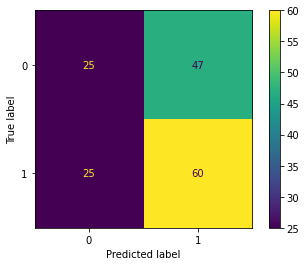

In [75]:
plot_confusion_matrix(model, X_test, y_test)

It is interesting how the model actually mislabeles the winning matches for the home team less often than expected, yet mislabeles the losing matches quite often. But again, the low accuracy was to be expected - after all, we are missing some key components. We only have one dummy variable per player, so they are expected to have a kind of average performance of that player over all his (potentially many) years of playing in KHL.

The easiest way to fix that would be adding an extra set of columns conditional on the player and the seasons ID. That would turn the player's performance into an average over a specific season and should significantly improve the model. We could also add the same kind of interractions between all other variables such as player-team and team-season.

Ideally, we would even want to create dummies for player-player interactions, capturing the synergy between them. However, that would create a number of features equal to the number of players to power of 2 (around 10 million) and even after dropping the all-null columns (since most of the players have probably only played with a few dozen or hundred players) it could still leave us in the ballpark of several hundred thousand features. Not only is such a model extremely prone to overfitting but it is also very computationally heavy.